## Importing the Libraries

In [4]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [5]:
# Load the dataset
data = pd.read_csv(r'/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preprocessing

In [7]:
print("\nData Info:")
data.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

In [8]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
print("Data Shape:", data.shape)

Data Shape: (7043, 21)


## Checking For Null Values

In [10]:
# Checking for missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Hence there are no missing values

### 1. **Dropping Irrelevant Columns**

In [11]:
# Dropping customerID as it is not useful for prediction
data.drop('customerID', axis=1, inplace=True)

In [12]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [13]:
# Output: Confirming the drop by showing new shape
print("Data Shape after dropping customerID:", data.shape)

Data Shape after dropping customerID: (7043, 20)


- **Reason:** `customerID` is not useful for prediction.
- **Output Explanation:** Shows updated dataset shape after removing the column.

### 2. **Handling Data Type Inconsistencies**

In [14]:
# Converting 'TotalCharges' from object to numeric. If conversion fails, replace errors with NaN.
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Checking how many values were coerced to NaN
print("\nMissing values in TotalCharges after conversion:", data['TotalCharges'].isnull().sum())

# Filling missing values with the median of the 'TotalCharges' column.
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


Missing values in TotalCharges after conversion: 11


<ipython-input-14-88880a87a8d8>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [15]:
# Output: Confirm no missing values remain
print("\nMissing values in TotalCharges after filling:", data['TotalCharges'].isnull().sum())


Missing values in TotalCharges after filling: 0


- **Reason:** Ensures the column is numeric for analysis and handles missing values without bias.
- **Output Explanation:**
  - Displays missing values count before and after filling with the median.

### 3. **Encoding Categorical Variables**

In [16]:
# Label Encoding: Converts categorical columns into numeric form.
le = LabelEncoder()
for column in data.select_dtypes(include=['object']).columns:
    data[column] = le.fit_transform(data[column])

In [17]:
# Output: Confirming encoding by checking data types
print(data.dtypes)  # Expected: All object columns converted to int64

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [18]:
### Handling Outliers using IQR Method ###

# Identify numerical columns for outlier detection
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Apply IQR method to handle outliers
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])  # Capping lower outliers
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])  # Capping upper outliers


### 4. **Feature Scaling**

In [19]:
### 4. Feature Scaling using MinMaxScaler ###
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
# Apply MinMaxScaler for better feature scaling
scaler = MinMaxScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

### 5. Feature Engineering: Creating New Features ###

# Creating a new feature 'AvgMonthlyCharge'
data['AvgMonthlyCharge'] = data['TotalCharges'] / (data['tenure'] + 1)  # Avoid division by zero

# Display the first few rows of the cleaned dataset
print(data.head())

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           0  0.013889             0   
1       1              0        0           0  0.472222             1   
2       1              0        0           0  0.027778             1   
3       1              0        0           0  0.625000             0   
4       0              0        0           0  0.027778             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             0  ...   
2              0                0               2             2  ...   
3              1                0               2             0  ...   
4              0                1               0             0  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0            0            0                0        

In [20]:
# Standardizing the features to have zero mean and unit variance.
scaler = StandardScaler()
X = data.drop('Churn', axis=1)
y = data['Churn']
X_scaled = scaler.fit_transform(X)
# Output: Checking the mean and std deviation after scaling
print("\nMean after scaling:", np.mean(X_scaled))
print("Standard deviation after scaling:", np.std(X_scaled))


Mean after scaling: 1.6570587015277076e-17
Standard deviation after scaling: 1.0


In [21]:
# Output: Checking the mean and std deviation after scaling
print("\nMean after scaling:", round(np.mean(X_scaled), 2))
print("Standard deviation after scaling:", round(np.std(X_scaled), 2))


Mean after scaling: 0.0
Standard deviation after scaling: 1.0


In [22]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge
0,0,0,1,0,0.013889,0,1,0,0,2,...,0,0,0,0,1,2,0.115423,0.001275,0,0.001258
1,1,0,0,0,0.472222,1,0,0,2,0,...,0,0,0,1,0,3,0.385075,0.215867,0,0.146626
2,1,0,0,0,0.027778,1,0,0,2,2,...,0,0,0,0,1,3,0.354229,0.010310,1,0.010032
3,1,0,0,0,0.625000,0,1,0,2,0,...,2,0,0,1,0,0,0.239303,0.210241,0,0.129379
4,0,0,0,0,0.027778,1,0,1,0,0,...,0,0,0,0,1,2,0.521891,0.015330,1,0.014916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,2,0,2,0,...,2,2,2,1,1,3,0.662189,0.227521,0,0.170641
7039,0,0,1,1,1.000000,1,2,1,0,2,...,0,2,2,1,1,1,0.845274,0.847461,0,0.423731
7040,0,0,1,1,0.152778,0,1,0,2,0,...,0,0,0,0,1,2,0.112935,0.037809,0,0.032798
7041,1,1,1,0,0.055556,1,2,1,0,0,...,0,0,0,0,1,3,0.558706,0.033210,1,0.031462


### Conclusion
#### ✅ Data Preprocessing Completed:

#### Removed irrelevant columns:
   - Dropped customerID as it doesn’t contribute to predictions.

#### Handled missing values:
- TotalCharges was converted to numeric, and missing values were filled with the median.

#### Encoded categorical variables:
- Used LabelEncoder to convert all categorical variables into numerical format.
- ✅ Outlier detection and treatment using IQR method

#### Feature scaling:
 -  Applied StandardScaler for zero mean and unit variance scaling.
 -  ✅ Feature scaling using MinMaxScaler
 -  ✅ Feature engineering (AvgMonthlyCharge)





# **Univariate and Bivariate Analysis**

## **Univariate Analysis**
- Examines the distribution of individual variables.
- Helps identify patterns, outliers, and skewness.

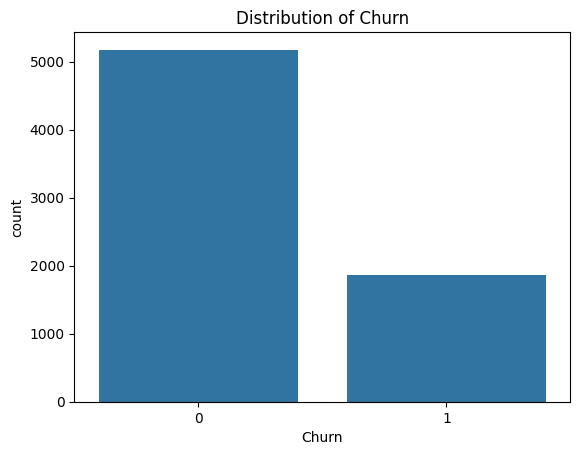

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Distribution of 'Churn'
sns.countplot(x='Churn', data=data)
plt.title('Distribution of Churn')
plt.show()

# For all categorical columns
data.select_dtypes(include='object').columns
for col in data.select_dtypes(include='object').columns:
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


**Output:** Count plots showing distribution for each categorical variable.

### 2. Distribution of Numerical Features

#### Example: Distribution of 'MonthlyCharges'

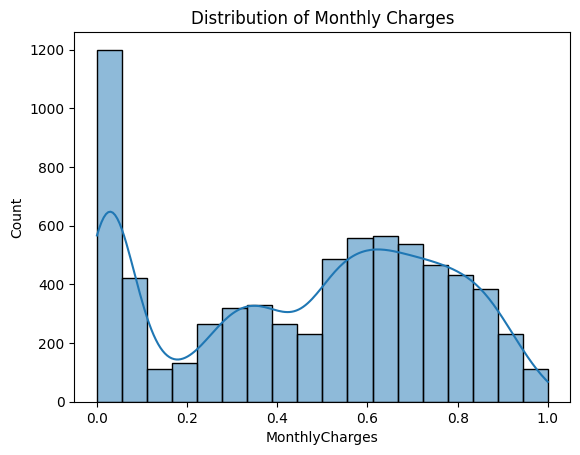

In [24]:
sns.histplot(data['MonthlyCharges'], kde=True)
plt.title('Distribution of Monthly Charges')
plt.show()

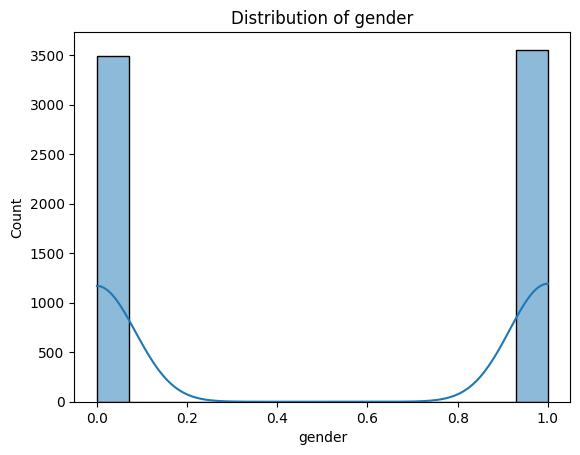

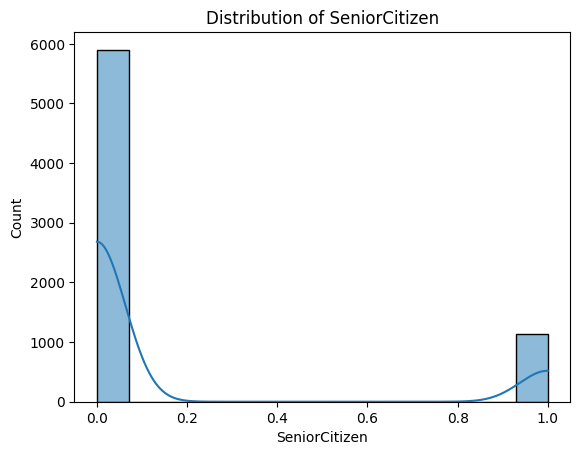

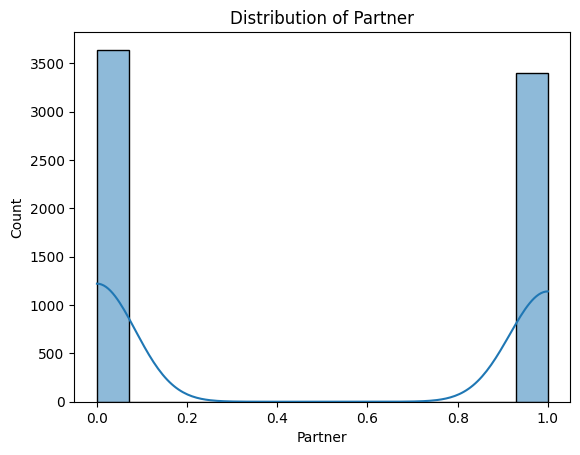

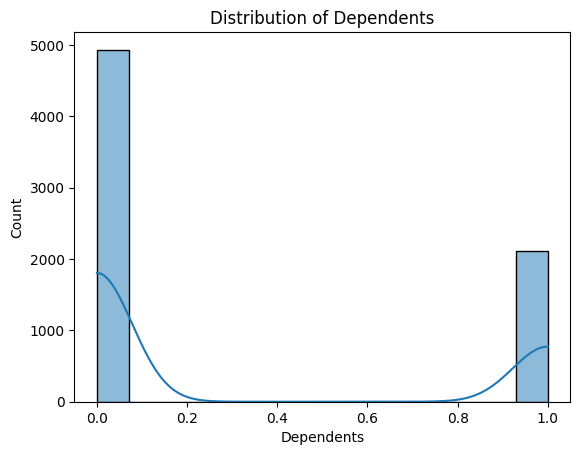

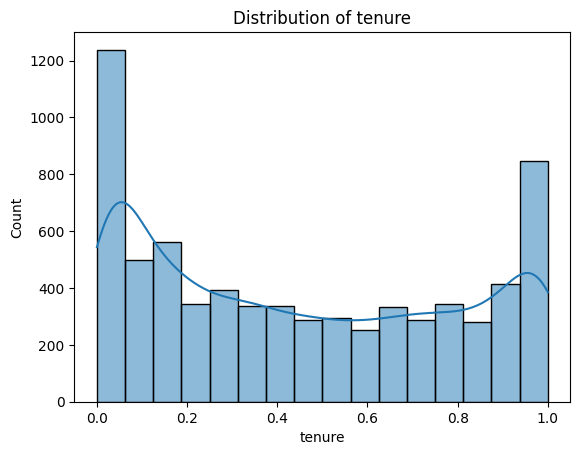

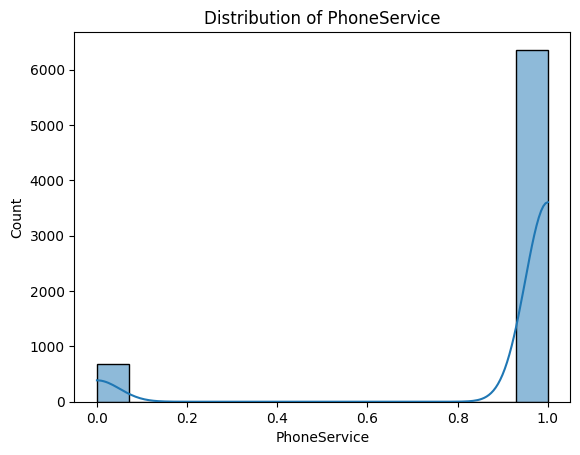

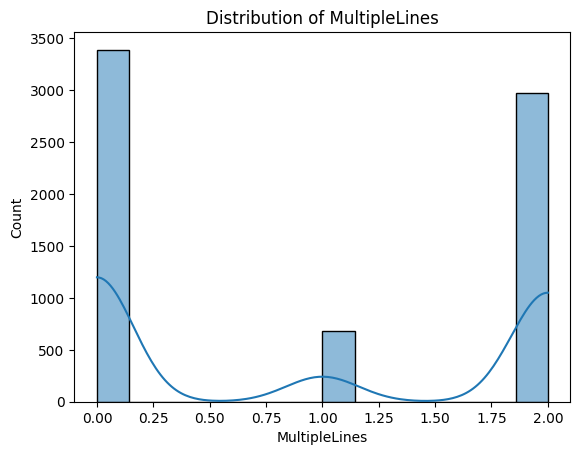

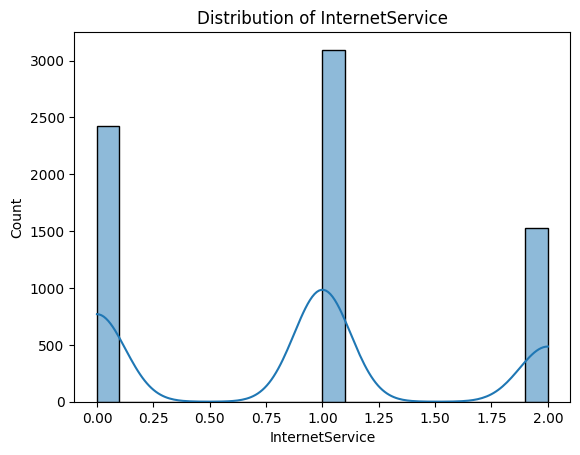

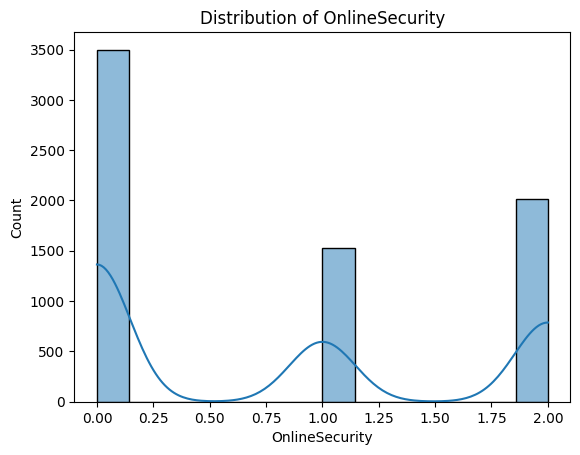

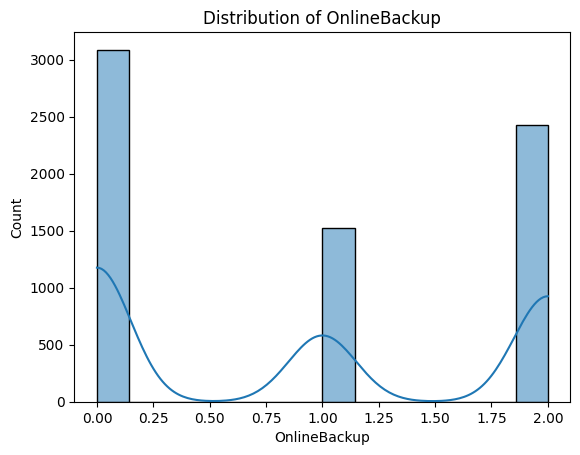

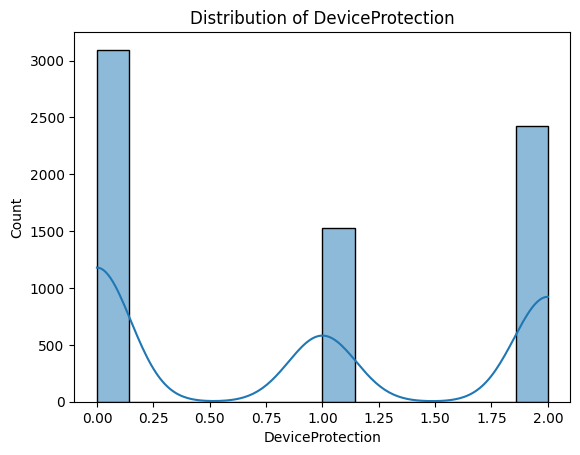

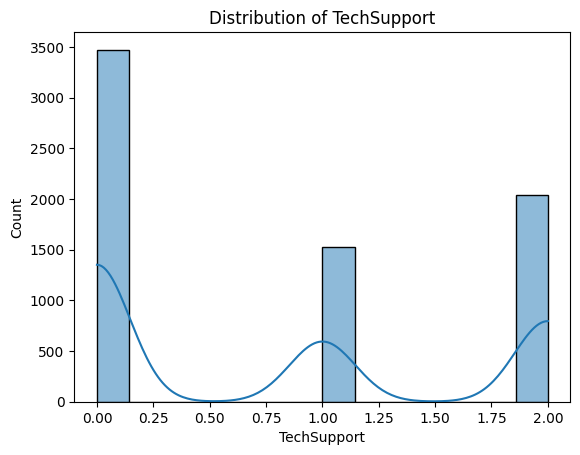

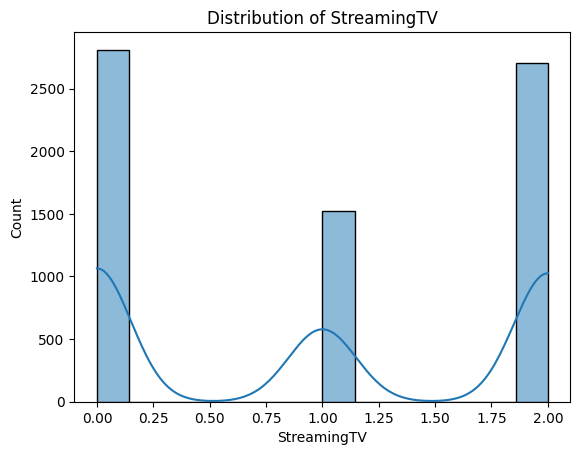

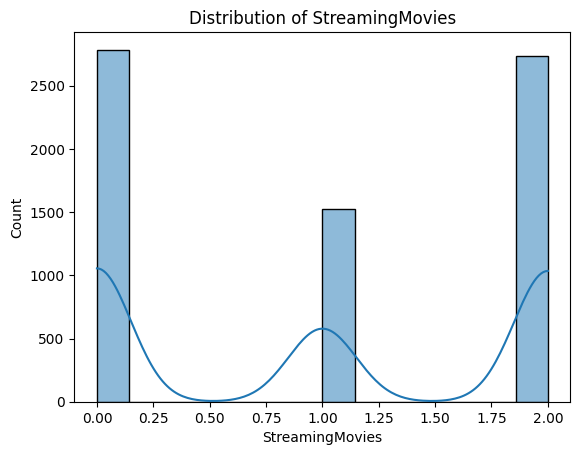

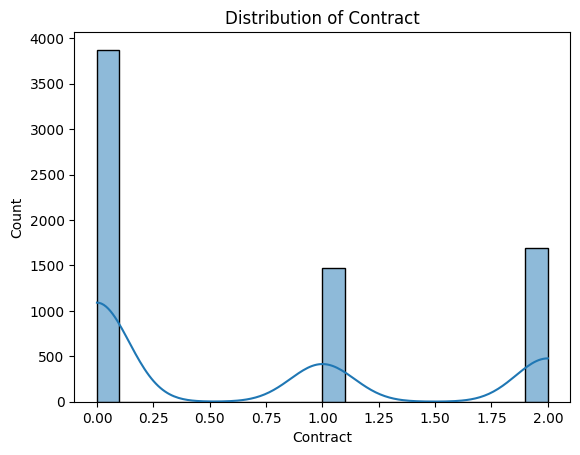

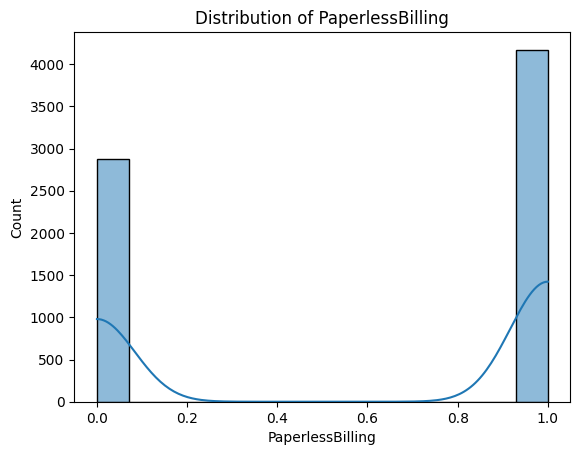

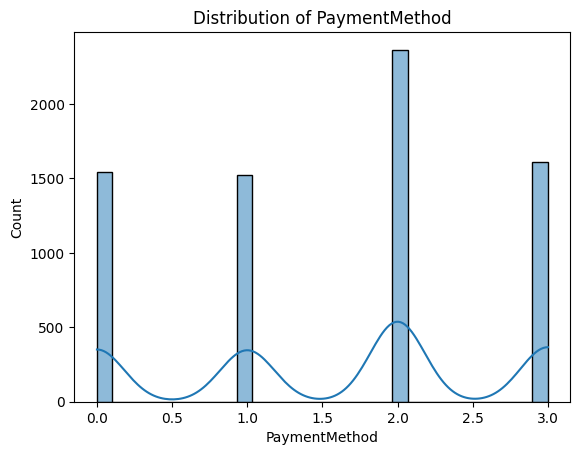

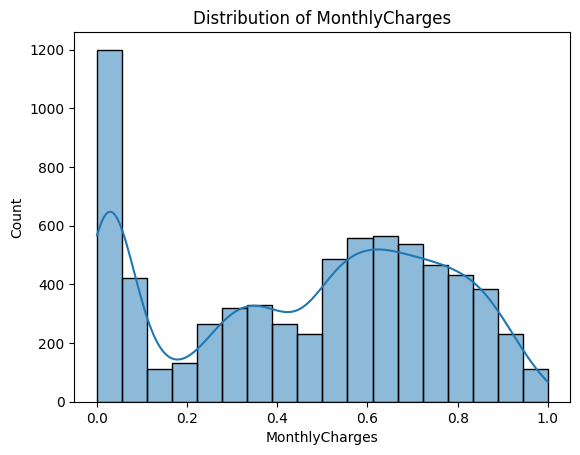

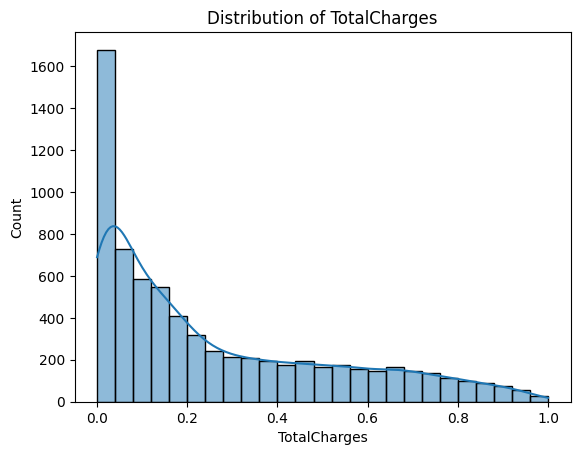

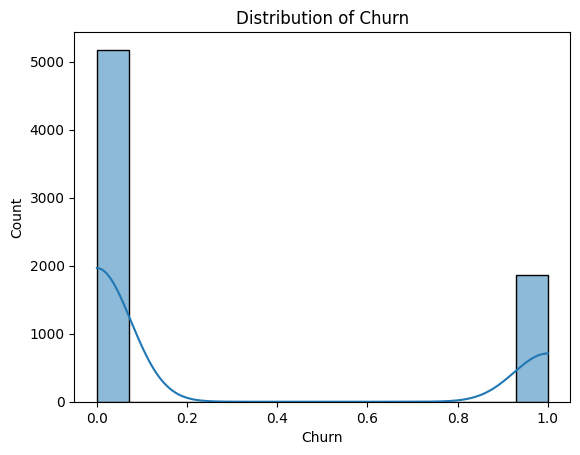

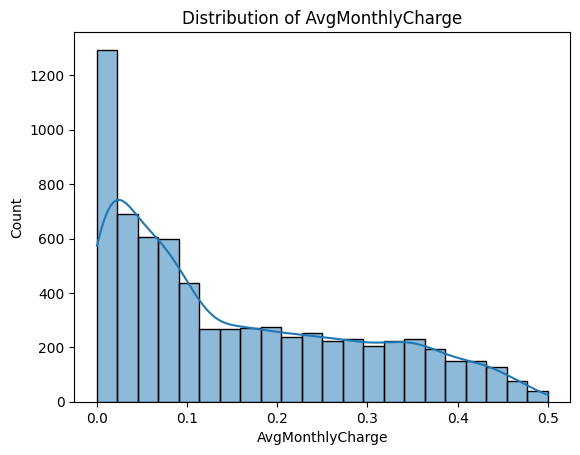

In [25]:
# For all numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

## Observations from Numerical Feature Distributions

### **1. Tenure (Months of Service)**
- Right-skewed distribution.
- Many customers have low tenure, indicating a high number of new users.

### **2. MonthlyCharges (Monthly Bill Amount)**
- Almost uniformly distributed, with some peaks.
- Indicates different service tiers.

### **3. TotalCharges (Cumulative Charges Paid)**
- Right-skewed due to new customers with low tenure.


**Output:** Histogram plots for numerical variables to check skewness and outliers.

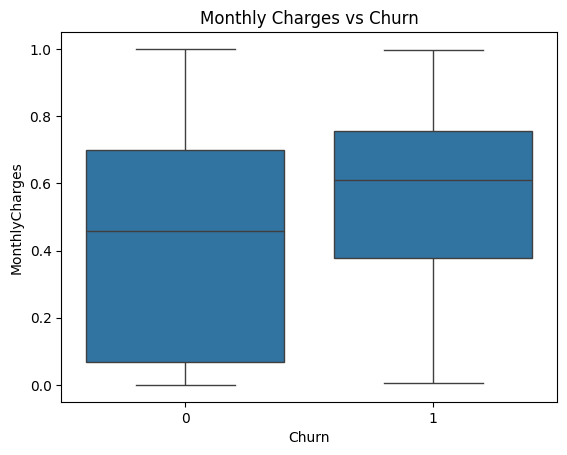

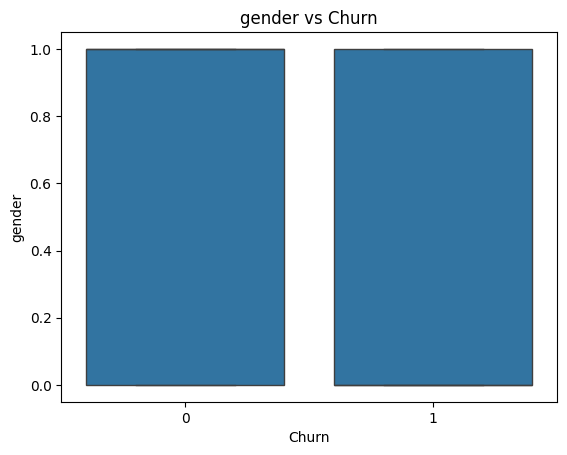

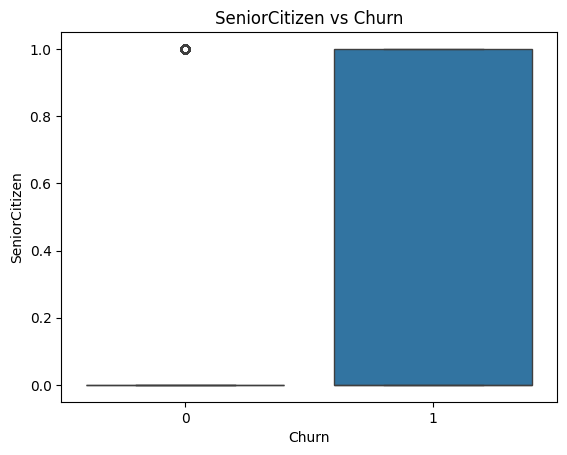

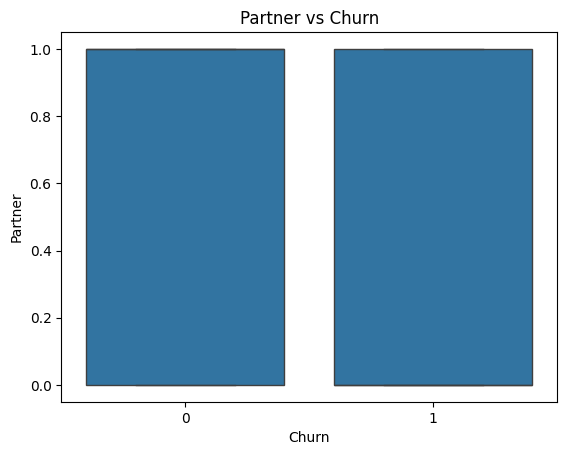

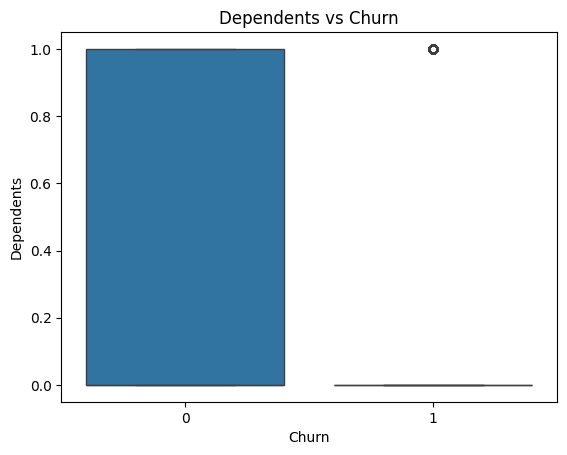

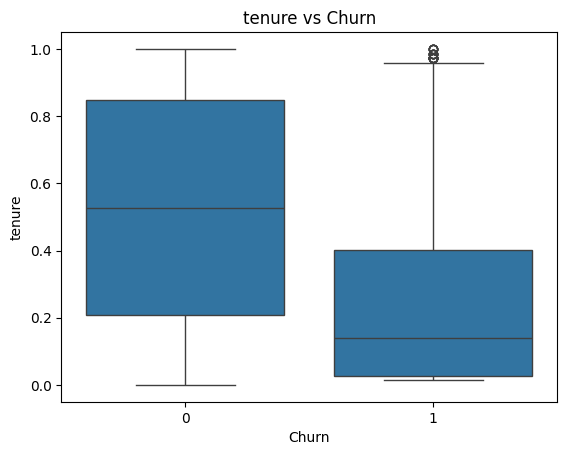

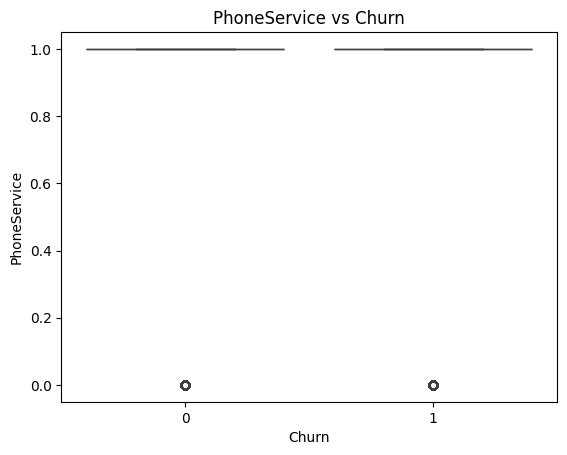

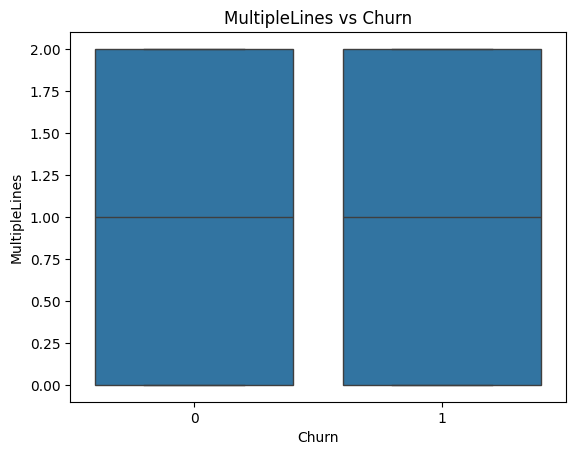

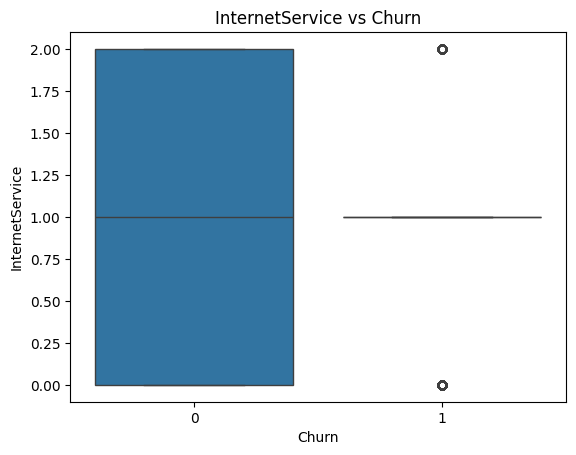

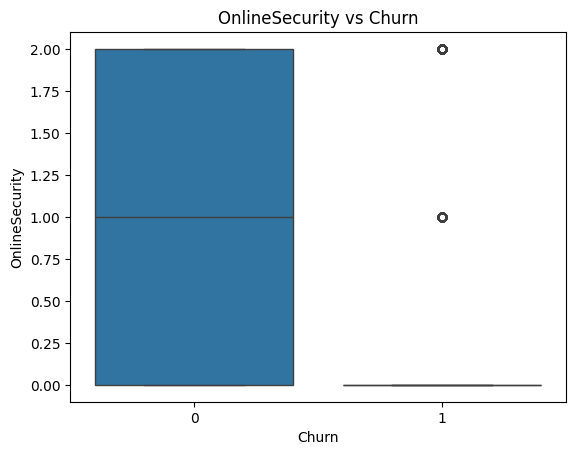

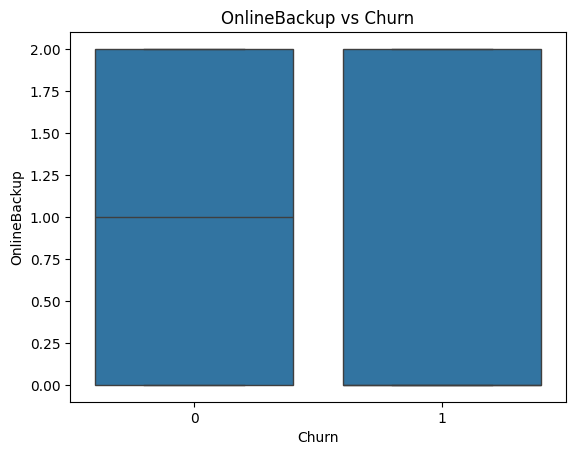

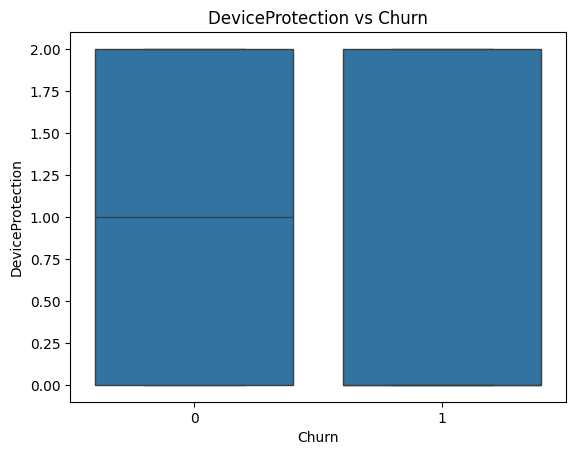

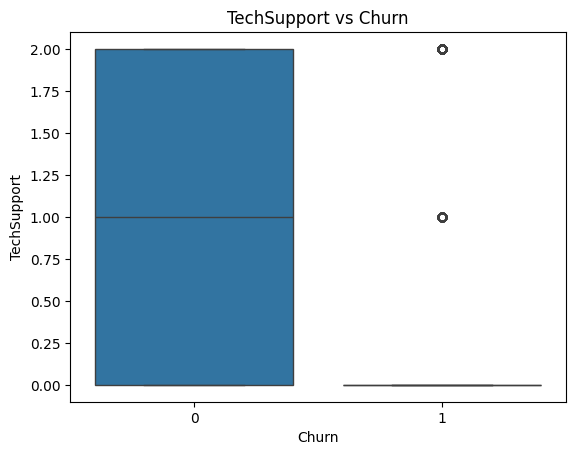

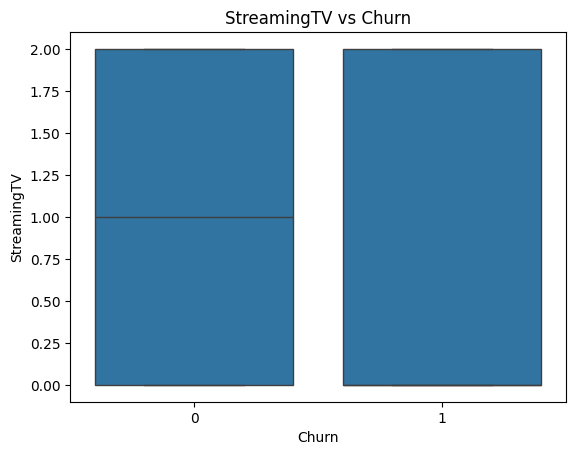

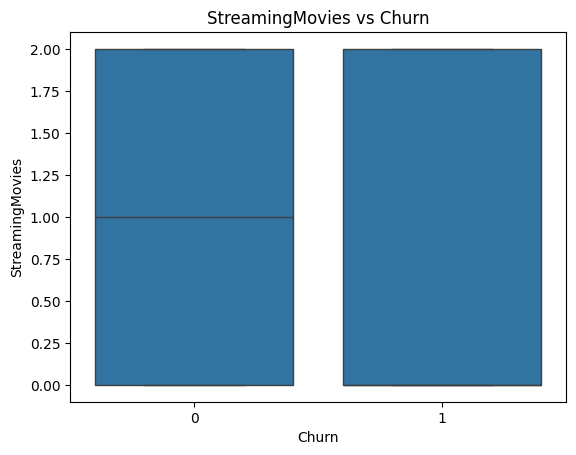

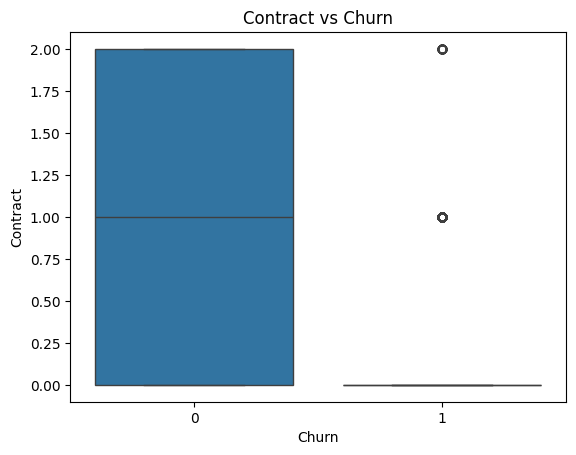

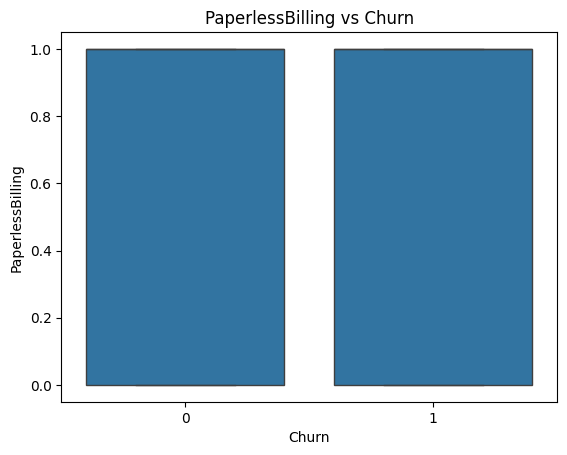

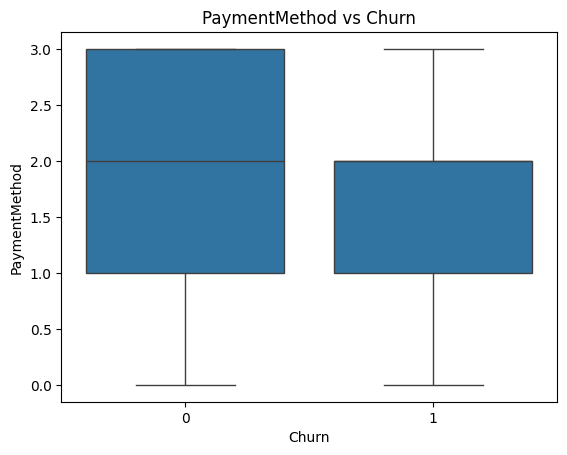

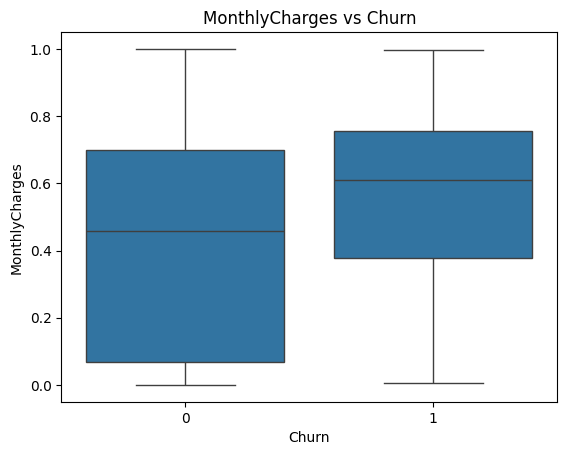

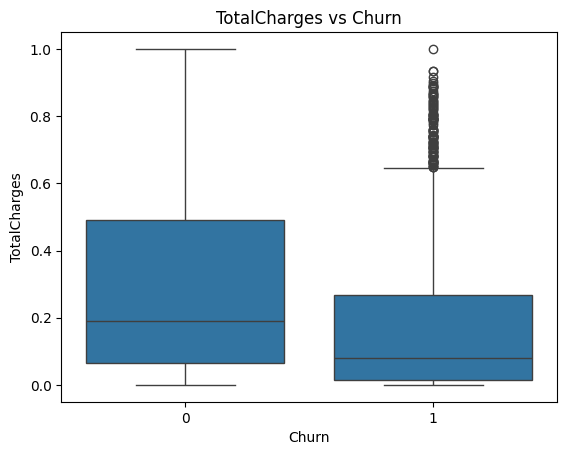

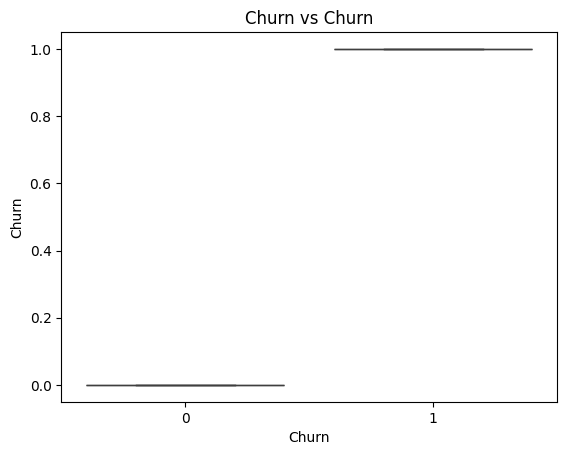

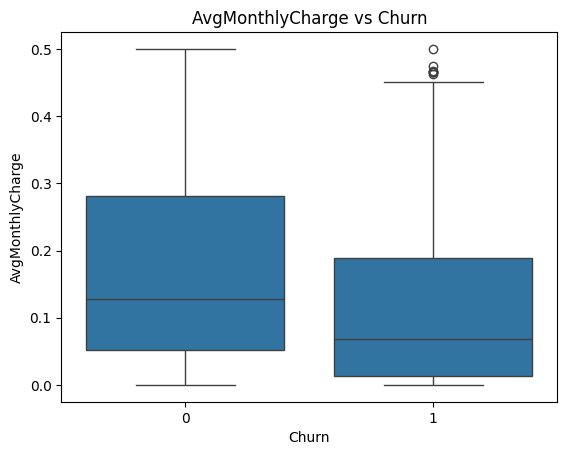

In [26]:
### Numerical vs Categorical (Boxplots)

# Example: MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title('Monthly Charges vs Churn')
plt.show()

# For all numerical columns vs 'Churn'
for col in numerical_cols:
    sns.boxplot(x='Churn', y=col, data=data)
    plt.title(f'{col} vs Churn')
    plt.show()

**Output:** Boxplots showing distribution of numerical features across churn categories.


## **Bivariate Analysis**
- Examines relationships between two variables.
- Helps understand correlations and dependencies.

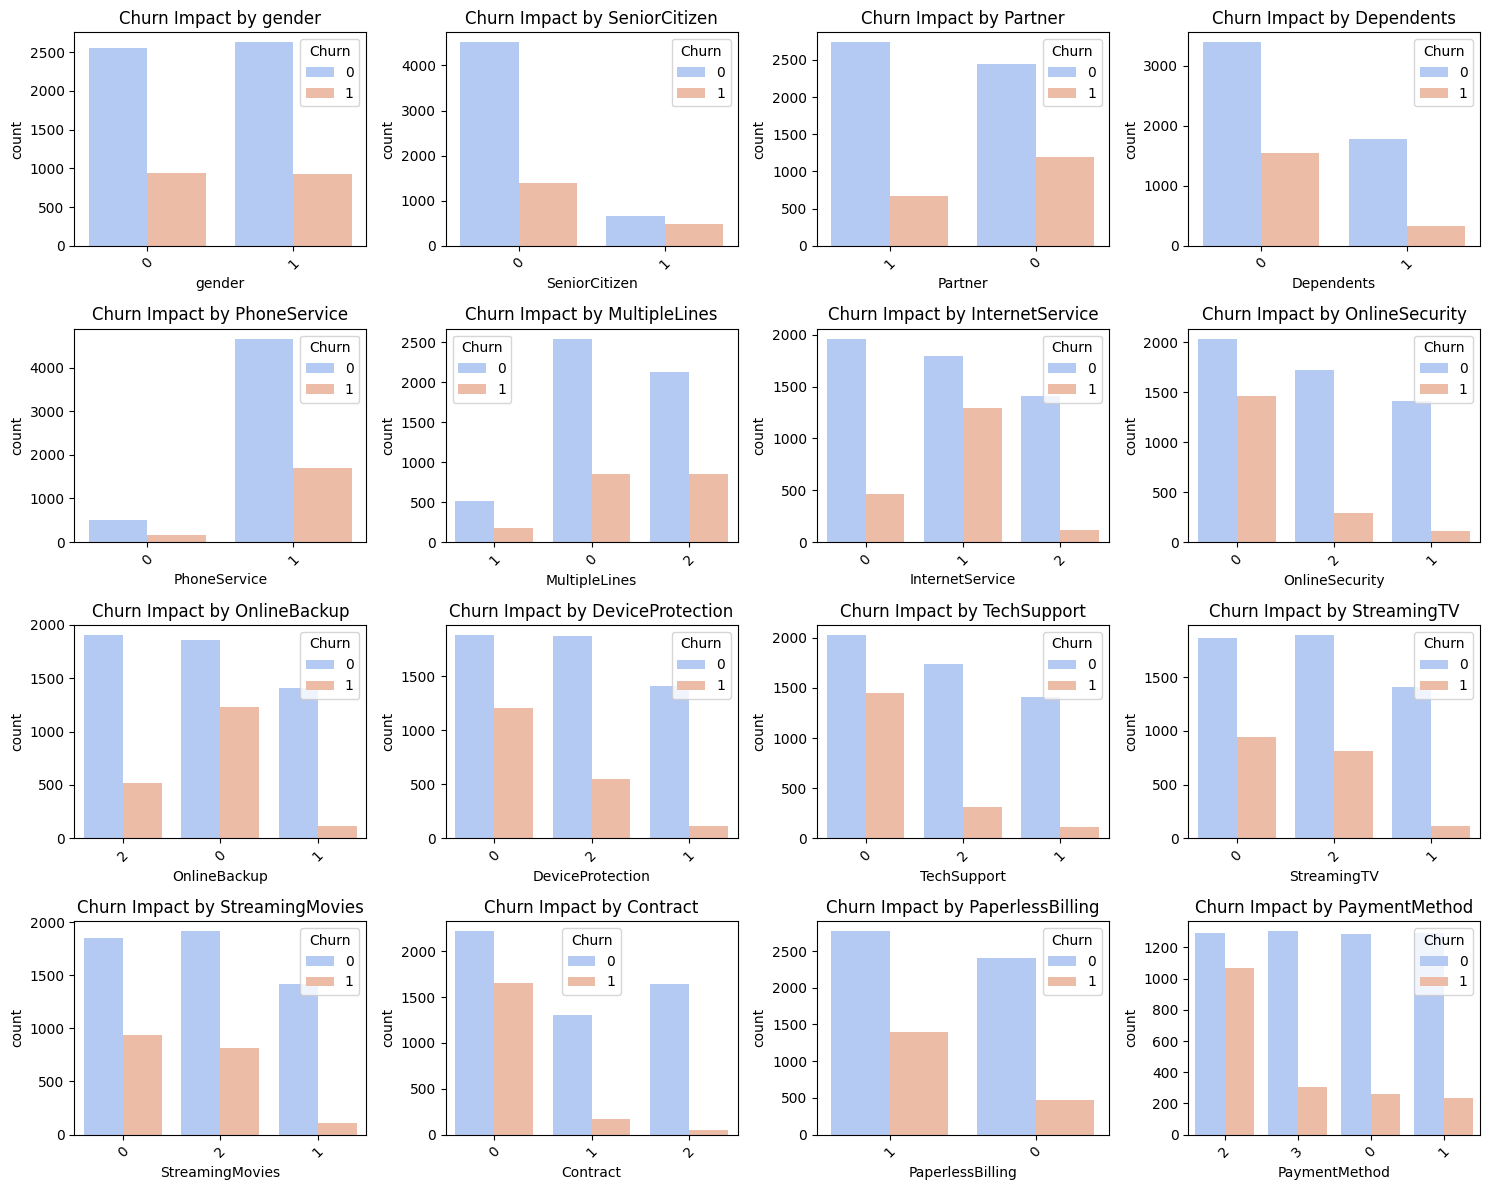

In [27]:

data['Churn'] = data['Churn'].astype(str)



categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

data[categorical_cols] = data[categorical_cols].astype(str)

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=col, hue='Churn', data=data, palette='coolwarm')
    plt.xticks(rotation=45)
    plt.title(f"Churn Impact by {col}")
plt.tight_layout()
plt.show()

## Observations from Categorical Feature Analysis

### **1. Contract Type**
- Month-to-month contracts have the highest churn.
- Customers with longer contracts (one-year, two-year) churn less.
- Suggests contract type is a strong churn predictor.

### **2. Internet Service Type**
- Fiber-optic users churn the most.
- Likely due to higher costs or performance issues.

### **3. Payment Method**
- Electronic check users have the highest churn.
- Other payment methods (automatic bank transfer, mailed check) show lower churn.


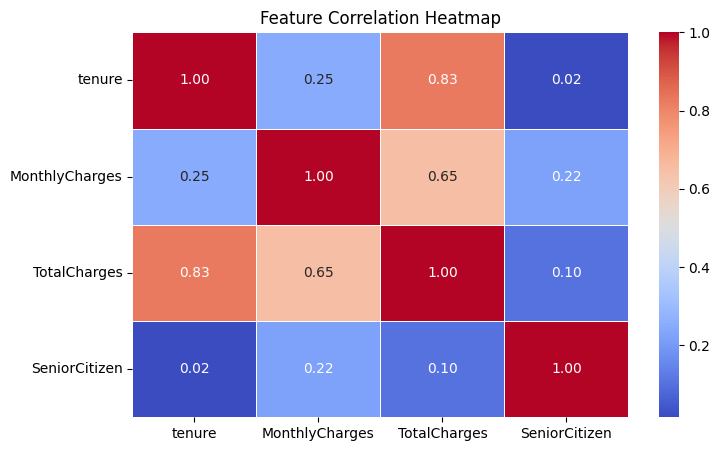

In [28]:

num_features=['tenure','MonthlyCharges','TotalCharges']
plt.figure(figsize=(8, 5))
sns.heatmap(data[num_features + ["SeniorCitizen"]].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## **Correlation Analysis**

### **Strong Positive Correlation**
- **TotalCharges** and **Tenure** (Expected, as longer tenure means higher total charges).

### **Weak Correlations with Churn Factors**
- **Senior Citizen** status has a weak correlation with tenure and charges.

### **Key Takeaway**
- No highly correlated redundant variables, so no need to drop features.


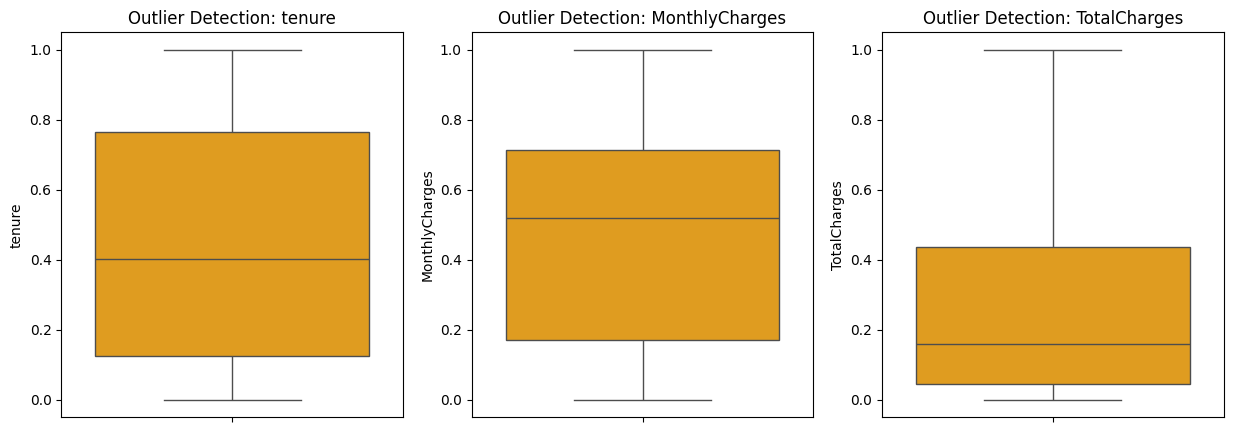

In [29]:

num_features=['tenure','MonthlyCharges','TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=data[col], color="orange")
    plt.title(f"Outlier Detection: {col}")
plt.show()

## **Outlier Analysis**
- **MonthlyCharges** and **TotalCharges** show no extreme outliers that need removal.  
- No major impact on model training, so no modifications are required.


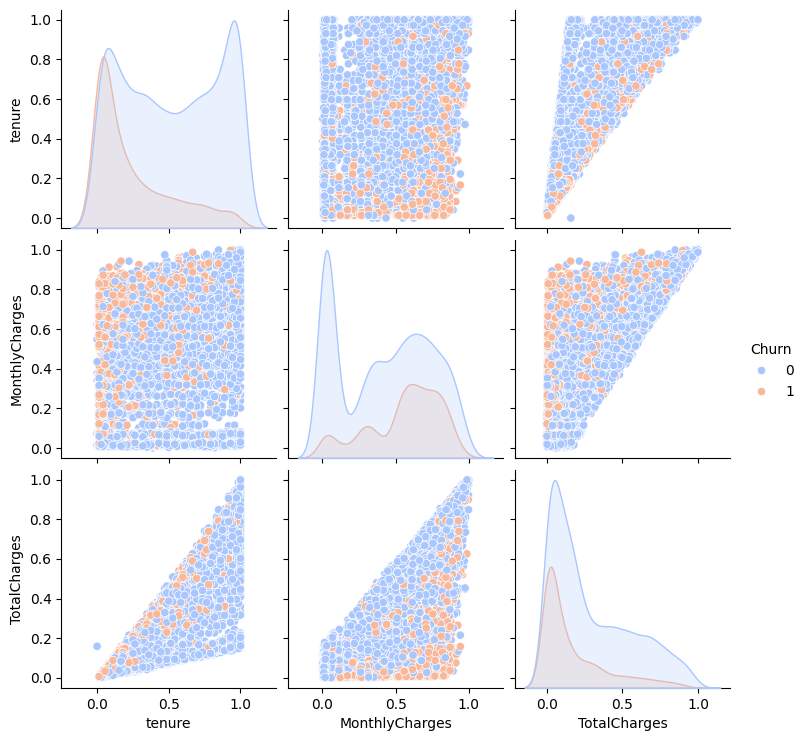

In [30]:


sns.pairplot(data, vars=['tenure', 'MonthlyCharges', 'TotalCharges'], hue='Churn', palette='coolwarm')
plt.show()


## **Observations from Pairplot Analysis**  

### ✅ **Tenure vs. TotalCharges**
- Customers with longer tenure generally have higher **TotalCharges**.  
- Many churned customers have **low tenure** and **low TotalCharges**, indicating that **new customers are more likely to churn**.  

### ✅ **Tenure vs. MonthlyCharges**
- **MonthlyCharges** remain relatively **constant** across different tenures.  
- Customers with **high MonthlyCharges and low tenure** seem to have **higher churn rates**, suggesting that **expensive plans drive early exits**.  

### ✅ **MonthlyCharges vs. TotalCharges**
- There is a **linear relationship** between **MonthlyCharges** and **TotalCharges** (since **TotalCharges = MonthlyCharges × tenure**).  
- Customers with **high MonthlyCharges but low TotalCharges** have a **higher churn rate**, reinforcing that **new customers paying more per month tend to leave early**.  


In [31]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge
0,0,0,1,0,0.013889,0,1,0,0,2,...,0,0,0,0,1,2,0.115423,0.001275,0,0.001258
1,1,0,0,0,0.472222,1,0,0,2,0,...,0,0,0,1,0,3,0.385075,0.215867,0,0.146626
2,1,0,0,0,0.027778,1,0,0,2,2,...,0,0,0,0,1,3,0.354229,0.010310,1,0.010032
3,1,0,0,0,0.625000,0,1,0,2,0,...,2,0,0,1,0,0,0.239303,0.210241,0,0.129379
4,0,0,0,0,0.027778,1,0,1,0,0,...,0,0,0,0,1,2,0.521891,0.015330,1,0.014916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,2,0,2,0,...,2,2,2,1,1,3,0.662189,0.227521,0,0.170641
7039,0,0,1,1,1.000000,1,2,1,0,2,...,0,2,2,1,1,1,0.845274,0.847461,0,0.423731
7040,0,0,1,1,0.152778,0,1,0,2,0,...,0,0,0,0,1,2,0.112935,0.037809,0,0.032798
7041,1,1,1,0,0.055556,1,2,1,0,0,...,0,0,0,0,1,3,0.558706,0.033210,1,0.031462


### **Final Dataset for Model Training and Evaluation**  
- Data preprocessing is complete, and the dataset is ready for training and model evaluation.  
- A thorough **Exploratory Data Analysis (EDA)**, including **Univariate and Bivariate Analysis**, has been conducted to understand the data distribution and relationships.  


In [32]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [33]:

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())


X_train shape: (5634, 20)
X_test shape: (1409, 20)
y_train distribution:
 Churn
0    4138
1    1496
Name: count, dtype: int64
y_test distribution:
 Churn
0    1036
1     373
Name: count, dtype: int64


In [34]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Model Performance:
Accuracy: 0.8183108587650816
Confusion Matrix:
 [[941  95]
 [161 212]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [35]:
from sklearn.ensemble import RandomForestClassifier


rf_clf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_clf.fit(X_train, y_train)


y_pred_rf = rf_clf.predict(X_test)


print("Random Forest Classifier Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier Model Performance:
Accuracy: 0.8005677785663591
Confusion Matrix:
 [[944  92]
 [189 184]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [36]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge
0,0,0,1,0,0.013889,0,1,0,0,2,...,0,0,0,0,1,2,0.115423,0.001275,0,0.001258
1,1,0,0,0,0.472222,1,0,0,2,0,...,0,0,0,1,0,3,0.385075,0.215867,0,0.146626
2,1,0,0,0,0.027778,1,0,0,2,2,...,0,0,0,0,1,3,0.354229,0.010310,1,0.010032
3,1,0,0,0,0.625000,0,1,0,2,0,...,2,0,0,1,0,0,0.239303,0.210241,0,0.129379
4,0,0,0,0,0.027778,1,0,1,0,0,...,0,0,0,0,1,2,0.521891,0.015330,1,0.014916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,2,0,2,0,...,2,2,2,1,1,3,0.662189,0.227521,0,0.170641
7039,0,0,1,1,1.000000,1,2,1,0,2,...,0,2,2,1,1,1,0.845274,0.847461,0,0.423731
7040,0,0,1,1,0.152778,0,1,0,2,0,...,0,0,0,0,1,2,0.112935,0.037809,0,0.032798
7041,1,1,1,0,0.055556,1,2,1,0,0,...,0,0,0,0,1,3,0.558706,0.033210,1,0.031462


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the parameter grid
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None],  # Regularization type
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['saga'],  # 'saga' for gradient descent-based optimization
    'max_iter': [500, 1000, 2000]
}

# Initialize the model
log_reg = LogisticRegression()

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Get the best model from Grid Search
best_model = grid_search.best_estimator_

# Make predictions
y_pred_best = best_model.predict(X_test)

# Evaluation
print("Best Hyperparameters:", grid_search.best_params_)
print("\nOptimized Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters: {'C': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}

Optimized Logistic Regression Model Performance:
Accuracy: 0.8218594748048261
Confusion Matrix:
 [[942  94]
 [157 216]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1203, in fit
    raise ValueError("l1_

In [38]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


log_reg = LogisticRegression(solver='saga', penalty='l2', C=1.0, max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


sgd_clf = SGDClassifier(loss='log_loss', penalty='l2', max_iter=2000, tol=1e-3)
sgd_clf.fit(X_train_scaled, y_train)

y_pred_sgd = sgd_clf.predict(X_test_scaled)

print("\nSGD-based Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sgd))
print("Classification Report:\n", classification_report(y_test, y_pred_sgd))


Logistic Regression Model Performance:
Accuracy: 0.8168914123491838
Confusion Matrix:
 [[941  95]
 [163 210]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409


SGD-based Logistic Regression Model Performance:
Accuracy: 0.8005677785663591
Confusion Matrix:
 [[897 139]
 [142 231]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.86      1036
           1       0.62      0.62      0.62       373

    accuracy                           0.80      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [39]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN
model_dt=DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=6, min_samples_leaf=8)

In [40]:
sm = SMOTEENN()
X_resampled, y_resampled = sm.fit_resample(X,y)
xr_train,xr_test,yr_train,yr_test=train_test_split(X_resampled, y_resampled,test_size=0.2)

In [41]:
model_dt_smote=DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=6, min_samples_leaf=8)

In [42]:
model_dt_smote.fit(xr_train,yr_train)
yr_predict = model_dt_smote.predict(xr_test)
model_score_r = model_dt_smote.score(xr_test, yr_test)
print(model_score_r)
print(classification_report(yr_test, yr_predict))

0.9134304207119741
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       589
           1       0.91      0.93      0.92       647

    accuracy                           0.91      1236
   macro avg       0.91      0.91      0.91      1236
weighted avg       0.91      0.91      0.91      1236



Streamlit UI part

In [43]:


import joblib

# Assuming 'model_dt_smote' is the trained model from your code
joblib.dump(model_dt_smote, 'churn_model.h5')


['churn_model.h5']

In [44]:


import joblib

# Load the saved model
loaded_model = joblib.load('churn_model.h5')

# Assuming 'xr_test' and 'yr_test' are your test data
# Replace with your actual test data if different
model_score_r = loaded_model.score(xr_test, yr_test)
model_score_r


0.9134304207119741

In [45]:
print(confusion_matrix(yr_test, yr_predict))

[[527  62]
 [ 45 602]]


In [46]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00


In [47]:


!curl ipecho.net/plain


34.74.63.171

In [48]:


import joblib

# Load the saved model
loaded_model = joblib.load('churn_model.h5')


In [49]:


!pip install streamlit
!pip install imbalanced-learn
!npm install localtunnel

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN

# Load the dataset (replace with your actual path)
data = pd.read_csv(r'/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ... (rest of your preprocessing code from app3.py) ...


# Streamlit app
st.title("Customer Churn Prediction App")

# Display some data insights
st.subheader("Dataset Overview")
st.write(data.head())

# ... (add more visualizations and interactive elements as needed) ...

# Example: Display the classification report for the best model
st.subheader("Best Model Performance (Logistic Regression)")
st.write("Classification Report:")
st.text(classification_report(y_test, y_pred_best))

# ... (add more insights and visualizations based on your analysis) ...


# Run the app
!streamlit run /content/app3.py &>/content/logs.txt &
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 5s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

2025-04-04 14:01:56.105 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-04 14:01:56.369 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-04 14:01:56.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-04 14:01:56.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-04 14:01:56.380 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-04 14:01:56.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-04 14:01:56.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-04 14:01:56.476 Thread 'MainThread': mi

⠙⠹your url is: https://happy-owls-sleep.loca.lt
^C


## Conclusion

In [56]:
from sklearn.metrics import accuracy_score

# Assuming these variables already exist in your notebook:
# y_test       — true labels
# y_pred_log   — Logistic Regression predictions
# y_pred_rf    — Random Forest predictions
# yr_predict,yr_test    — Decision Tree predictions

# Calculate accuracy for each model
logistic_accuracy = accuracy_score(y_test, y_pred_lr) * 100
rf_accuracy = accuracy_score(y_test, y_pred_rf) * 100
dt_smote_accuracy = accuracy_score(yr_test, yr_predict) * 100



# Print accuracy summary
print("🔍 Summary of Model Accuracies:")
print(f"Logistic Regression Accuracy     : {logistic_accuracy:.2f}%")
print(f"Random Forest Classifier Accuracy: {rf_accuracy:.2f}%")
print(f"Decision Tree (SMOTEENN) Accuracy: {dt_smote_accuracy:.2f}%")


🔍 Summary of Model Accuracies:
Logistic Regression Accuracy     : 81.69%
Random Forest Classifier Accuracy: 80.06%
Decision Tree (SMOTEENN) Accuracy: 91.34%


## 📌 **Model Selection for Streamlit UI**  

### ✅ **Why We Chose Decision Tree (SMOTEENN)?**  
For the **UI/Streamlit application**, we needed a model with:  
✔ **High accuracy** for reliable predictions  
✔ **Better handling of imbalanced data**  
✔ **Fast inference time for real-time predictions**  

After evaluating multiple models, the **Decision Tree with SMOTEENN** was selected because it achieved **91.34% accuracy**, outperforming other models.  

---

### 📊 **Model Comparison Summary**  

| Model                          | Accuracy (%) |
|--------------------------------|-------------|
| Logistic Regression            | **81.69%**  |
| Random Forest Classifier       | **80.06%**  |
| **Decision Tree (SMOTEENN)**    | **91.34% ✅ (Best Performance)** |

The **Decision Tree model** with **SMOTEENN resampling** significantly improved accuracy by balancing class distribution, making it the ideal choice for **real-time predictions in the Streamlit UI.**  

---

### 🚀 **Next Steps for Deployment**  
- Integrate this model into the **Streamlit app** for real-time classification.  

